## Oppgave 3)

In [182]:
#INITIALISERING

#Importering
import numpy as np
from matplotlib import pyplot as plt
from scipy.special import erfc
import pandas as pd
from IPython.display import display

#konstanter
params_oppgave_3 = {
    "alfa"      : 0.8,
    "Tp"        : 500,
    "Nx"        : 100,
    "beta_k"    : 1000   
}
params_oppgave_3["L"] = 2*params_oppgave_3["Nx"]
params_oppgave_3["Np"] = 12*params_oppgave_3["Nx"]
params_oppgave_3["timeSteps"] = 20*params_oppgave_3["Tp"]

In [183]:
#HJELPEFUNKSJONER

#Potensialer
def V1(x, params):                #uten k fordi den inngår i p_pos
    Nx = params["Nx"]
    alfa = params["alfa"]
    periode = x % Nx

    if periode <= alfa*Nx:
        return periode/(alfa*Nx)
    else:
        return (Nx-periode)/((1-alfa)*Nx)

def V2(x, params):                         
    return 0


#Sannsynlighetsfunksjoner p+ og p-
def p_pos(x, V, params):
    beta_k = params["beta_k"]
    L = params["L"]

    arg1 = np.clip(-beta_k*(V((x-1)%L,params)-V((x+1)%L,params)), -700, 700)
    arg2 = np.clip(-beta_k*(V(x%L,params)-V((x+1)%L,params)), -700, 700)

    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)

    return 1/nevner

def p_neg(x, V, params):
    beta_k = params["beta_k"]
    L = params["L"]

    arg1 = np.clip(-beta_k*(V((x+1)%L,params)-V((x-1)%L,params)), -700, 700)
    arg2 = np.clip(-beta_k*(V(x%L,params)-V((x-1)%L,params)), -700, 700)

    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)
    return 1/nevner


#Look-up tabeller for raskere kjøring
def lookUpTabell_V1(params):
    L = params["L"]

    tabell_V1_p_pos = np.zeros(L)
    tabell_V1_p_neg = np.zeros(L)

    for x in range(L):
        tabell_V1_p_pos[x] = p_pos(x, V1, params)
        tabell_V1_p_neg[x] = p_neg(x, V1, params)

    return tabell_V1_p_pos, tabell_V1_p_neg

def lookUpTabell_V2(params):
    L = params["L"]

    p_pos_val = p_pos(1, V2, params)
    p_neg_val = p_neg(1, V2, params)

    tabell_V2_p_pos = np.full(L, p_pos_val)
    tabell_V2_p_neg = np.full(L, p_neg_val)

    return tabell_V2_p_pos, tabell_V2_p_neg


#oppgave 3a hjelpefunksjoner
def syklusSnitt(current, params):
    syklus_len = 2*params["Tp"]
    n_cycles = len(current)//syklus_len
    return np.arange(1, n_cycles+1), np.array([current[n*syklus_len:(n+1)*syklus_len].mean() for n in range(n_cycles)])

def init_partikler_3a(params):
    L = params["L"]
    return np.repeat(np.arange(0,L), 6)


#oppgave 3b hjelpefunksjoner
def init_partikler_3b(params):
    Nx = params["Nx"]
    Np = params["Np"]
    return np.repeat([0,Nx], Np//2)


#oppgave 3c hjelpefunksjoner
def init_partikler_3c(params):
    Np = params["Np"]
    return np.zeros(Np, dtype=int)


In [ ]:
#SIMULERINGSFUNKSJONER

#oppgave 3 generelt
def particleCurrent_sim(partiklerPos, params, tabeller):
    timeSteps = params["timeSteps"]
    Tp = params["Tp"]
    L = params["L"]
    Np = params["Np"]
    startPot_pos_table = tabeller["startPot_pos_table"]
    startPot_neg_table = tabeller["startPot_neg_table"]
    secondPot_pos_table = tabeller["secondPot_pos_table"]
    secondPot_neg_table = tabeller["secondPot_neg_table"]

    particleCurrent = np.zeros(timeSteps)

    for k in range(timeSteps):
        hvilkenPotensial = ( k // Tp) % 2    
        n_pos = 0
        n_neg = 0
        if hvilkenPotensial == 0:
            tabell_p_pos, tabell_p_neg = startPot_pos_table, startPot_neg_table
        else:
            tabell_p_pos, tabell_p_neg = secondPot_pos_table, secondPot_neg_table
        
        randomtabell = np.random.rand(Np)

        posProb = tabell_p_pos[partiklerPos]
        negProb = tabell_p_neg[partiklerPos]

        neg_flytt = (randomtabell <= negProb)
        pos_flytt = (~neg_flytt) & (randomtabell >= (1 - posProb))

        partiklerPos[neg_flytt] -= 1
        partiklerPos[pos_flytt] += 1
        partiklerPos %= L

        n_pos = pos_flytt.sum()
        n_neg = neg_flytt.sum()
        particleCurrent[k] = (n_pos - n_neg)/Np

    return particleCurrent


#oppgave 3a
def oppgave_3a(params):
    lokal_params = params.copy()
    partiklerPos = init_partikler_3a(params = lokal_params)

    tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1(params = lokal_params)
    tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2(params = lokal_params)

    tabeller_potensial_3a = {
        "startPot_pos_table" : tabell_V2_p_pos,
        "startPot_neg_table" : tabell_V2_p_neg,
        "secondPot_pos_table": tabell_V1_p_pos,
        "secondPot_neg_table": tabell_V1_p_neg
    }

    particleCurrent = particleCurrent_sim(partiklerPos, params = lokal_params, tabeller = tabeller_potensial_3a)
    
    particleCurrent_syklusSnitt = syklusSnitt(particleCurrent, params = lokal_params)

    return particleCurrent_syklusSnitt


#oppgave 3b
def oppgave_3b(params):
    lokal_params = params.copy()
    lokal_params["Np"] = 40*lokal_params["Nx"]

    tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1(params = lokal_params)
    tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2(params = lokal_params)

    tabeller_potensial_3b = {
        "startPot_pos_table" : tabell_V2_p_pos,
        "startPot_neg_table" : tabell_V2_p_neg,
        "secondPot_pos_table": tabell_V1_p_pos,
        "secondPot_neg_table": tabell_V1_p_neg
    }

    Tp_array = np.round(np.linspace(1, 1001, 50)).astype(int)
    resultatarray = np.zeros(len(Tp_array))

    for i in range(len(Tp_array)):
        lokal_params["Tp"] = Tp_array[i]
        lokal_params["timeSteps"] = 2*lokal_params["Tp"]
        partiklerPos = init_partikler_3b(lokal_params)

        particleCurrent = particleCurrent_sim(partiklerPos, params = lokal_params, tabeller = tabeller_potensial_3b)

        resultatarray[i] = particleCurrent.mean()

    return Tp_array, resultatarray


#oppgave 3c
def oppgave_3c(params):
    lokal_params = params.copy()
    lokal_params["Tp"] = 500
    lokal_params["Np"] = 12*lokal_params["Nx"]
    lokal_params["timeSteps"] = 2*lokal_params["Tp"]

    alfa_array = np.linspace(0.01,1-0.01, 50)
    resultatarray = np.zeros(len(alfa_array))

    for i in range(len(alfa_array)):
        lokal_params["alfa"] = alfa_array[i]
        partiklerPos = init_partikler_3c(params = lokal_params)

        tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1(lokal_params)
        tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2(lokal_params)

        tabeller_potensial_3c = {
            "startPot_pos_table" : tabell_V2_p_pos,
            "startPot_neg_table" : tabell_V2_p_neg,
            "secondPot_pos_table": tabell_V1_p_pos,
            "secondPot_neg_table": tabell_V1_p_neg
        }
        particleCurrent = particleCurrent_sim(partiklerPos, params = lokal_params, tabeller = tabeller_potensial_3c)
        resultatarray[i] = particleCurrent.mean()
    
    Tp = lokal_params["Tp"]
    Nx = lokal_params["Nx"]

    analytisk_3c_array = (Nx/(4*Tp))*(erfc((alfa_array*Nx/2)*np.sqrt(3/Tp)) - erfc(((1-alfa_array)*Nx/2)*np.sqrt(3/Tp)))

    return alfa_array, resultatarray, analytisk_3c_array


#oppgave 3d
def oppgave_3d(params):
    lokal_params = params.copy()
    lokal_params["Tp"] = 500
    lokal_params["Np"] = 12*lokal_params["Nx"]
    lokal_params["timeSteps"] = 2*lokal_params["Tp"]

    alfa_array = np.linspace(0.01,1-0.01, 50)
    beta_k_array = np.array([0.01, 1, 2, 3, 5, 10])
    resultatarray = np.zeros((len(beta_k_array), len(alfa_array)))

    for k in range(len(beta_k_array)):
        lokal_params["beta_k"] = beta_k_array[k]
        mdltr_resultatarray = np.zeros(len(alfa_array))

        for i in range(len(alfa_array)):
            lokal_params["alfa"] = alfa_array[i]
            partiklerPos = init_partikler_3c(params = lokal_params)

            tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1(lokal_params)
            tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2(lokal_params)

            tabeller_potensial_3d = {
                "startPot_pos_table" : tabell_V2_p_pos,
                "startPot_neg_table" : tabell_V2_p_neg,
                "secondPot_pos_table": tabell_V1_p_pos,
                "secondPot_neg_table": tabell_V1_p_neg
            }
            particleCurrent = particleCurrent_sim(partiklerPos, params = lokal_params, tabeller = tabeller_potensial_3d)
            mdltr_resultatarray[i] = particleCurrent.mean()
        resultatarray[k, :] = mdltr_resultatarray

    Nx = lokal_params["Nx"]
    Tp = lokal_params["Tp"]

    analytisk_3d_array = (Nx/(4*Tp))*(erfc((alfa_array*Nx/2)*np.sqrt(3/Tp)) - erfc(((1-alfa_array)*Nx/2)*np.sqrt(3/Tp)))
    
    return alfa_array, resultatarray, analytisk_3d_array


#oppgave 3e
def oppgave_3e(params):
    lokal_params = params.copy()
    lokal_params["Nx"] = 10
    lokal_params["Np"] = 40*lokal_params["Nx"]
    lokal_params["alfa"] = 0.8

    tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1(params = lokal_params)
    tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2(params = lokal_params)

    tabeller_potensial_3e = {
        "startPot_pos_table" : tabell_V2_p_pos,
        "startPot_neg_table" : tabell_V2_p_neg,
        "secondPot_pos_table": tabell_V1_p_pos,
        "secondPot_neg_table": tabell_V1_p_neg
    }

    Tp_array = np.round(np.linspace(80, 1500, 20)).astype(int)
    resultatarray = np.zeros(len(Tp_array))

    for i in range(len(Tp_array)):
        lokal_params["Tp"] = Tp_array[i]
        lokal_params["timeSteps"] = 2*lokal_params["Tp"]
        partiklerPos = init_partikler_3b(lokal_params)

        particleCurrent = particleCurrent_sim(partiklerPos, params = lokal_params, tabeller = tabeller_potensial_3e)

        resultatarray[i] = particleCurrent.mean()
    
    Nx = lokal_params["Nx"]
    alfa = lokal_params["alfa"]

    analytisk_3e_array = (Nx/(4*Tp_array))*(erfc((alfa*Nx/2)*np.sqrt(3/Tp_array)) - erfc(((1-alfa)*Nx/2)*np.sqrt(3/Tp_array)))

    return Tp_array, resultatarray, analytisk_3e_array

In [185]:
#PLOTTEFUNKSJONER

#oppgave 3a
def plot_oppgave_3a(params, alfa=None):
    lokal_params = params.copy()

    if alfa is not None:
        lokal_params["alfa"] = alfa

    syklus_array, particleCurrent_3a = oppgave_3a(lokal_params)

    plt.figure(figsize=(8,4))
    plt.plot(syklus_array, particleCurrent_3a, marker="o", markersize=4)
    plt.axhline(0, color="black", linewidth=1, alpha=0.4)
    plt.xlim(1, syklus_array[-1])

    plt.xlabel(r"syklusnummer")
    plt.ylabel(r"$J_{avg}$ per syklus")
    plt.title(r"Oppgave 3a: gjennomsnittlig partikkelstrøm som funksjon av syklus")
    plt.grid(alpha=0.3)

    plt.show()
    df = pd.DataFrame({"syklus n": syklus_array, "$J_{avg}(n)$": particleCurrent_3a})
    display(df)


#oppgave 3b
def plot_oppgave_3b(params):
    Tp_array, particleCurrent_3b = oppgave_3b(params)
    
    plt.figure(figsize=(8,4))
    plt.plot(Tp_array, particleCurrent_3b)

    plt.xlabel(r"$T_p$")
    plt.ylabel(r"$J_{avg}$")
    plt.title(r"Oppgave 3b: gjennomsnittlig partikkelstrøm som funksjon av $T_p$")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


#oppgave 3c
def plot_oppgave_3c(params):
    alfa_array, particleCurrent_3c, analytisk_3c_array = oppgave_3c(params)

    plt.figure(figsize=(8,4))
    plt.plot(alfa_array, particleCurrent_3c, label="simulering")
    plt.plot(alfa_array, analytisk_3c_array, "k--", label="analytisk", alpha = 0.6)

    plt.xlabel(r"$\alpha$")
    plt.ylabel(r"$J_{\mathrm{avg}}$")
    plt.title(r"Oppgave 3c: gjennomsnittlig partikkelstrøm som funksjon av $\alpha$")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show() 


#oppgave 3d
def plot_oppgave_3d(params):
    alfa_array, particleCurrent_3d, analytisk_3d_array = oppgave_3d(params)

    beta_k_array = np.array([0.01, 1, 2, 3, 5, 10])

    plt.figure(figsize=(10,5))

    for beta_k, current in zip(beta_k_array, particleCurrent_3d):
        plt.plot(alfa_array, current, label=rf"$\beta k = {beta_k}$")

    plt.plot(alfa_array, analytisk_3d_array, "k--", label="analytisk", alpha = 0.6)

    plt.xlabel(r"$\alpha$")
    plt.ylabel(r"$J_{\mathrm{avg}}$")
    plt.title(r"Oppgave 3d: gjennomsnittlig partikkelstrøm som funksjon av $\alpha$")
    plt.grid(alpha=0.3)

    handles, labels = plt.gca().get_legend_handles_labels()

    plt.legend(handles[::-1], labels[::-1],
               bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()


# oppgave 3e
def plot_oppgave_3e(params):
    Tp_array, particleCurrent_3e, analytisk_3e_array = oppgave_3e(params)

    plt.figure(figsize=(8,4))

    plt.plot(Tp_array, particleCurrent_3e, label="simulering")
    plt.plot(Tp_array, analytisk_3e_array, "--", color="gray", label="analytisk")

    plt.xlabel(r"$T_p$")
    plt.ylabel(r"$J_{\mathrm{avg}}$")
    plt.title(r"Oppgave 3e: gjennomsnittlig partikkelstrøm som funksjon av $T_p$")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Oppgave 3a)

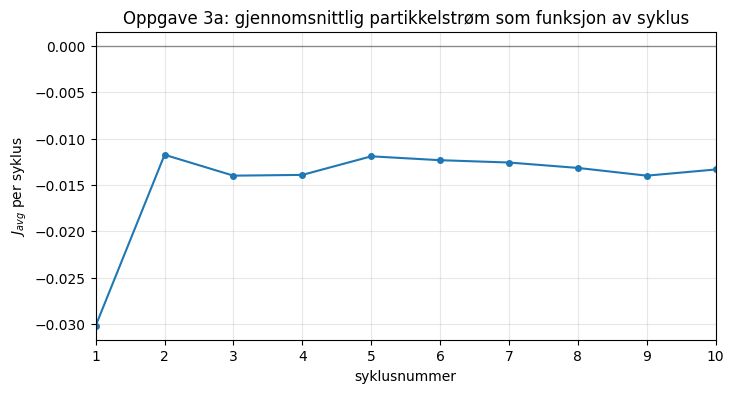

,syklus n,$J_{avg}(n)$
0,1,-0.030167
1,2,-0.011750
2,3,-0.014000
3,4,-0.013917
4,5,-0.011917
5,6,-0.012333
6,7,-0.012583
7,8,-0.013167
8,9,-0.014000
9,10,-0.013333


In [186]:
plot_oppgave_3a(params_oppgave_3)

SKRIVING:

WHY NON ZERO CURRENTS

SKRIVING:

COMPARE J(0)...

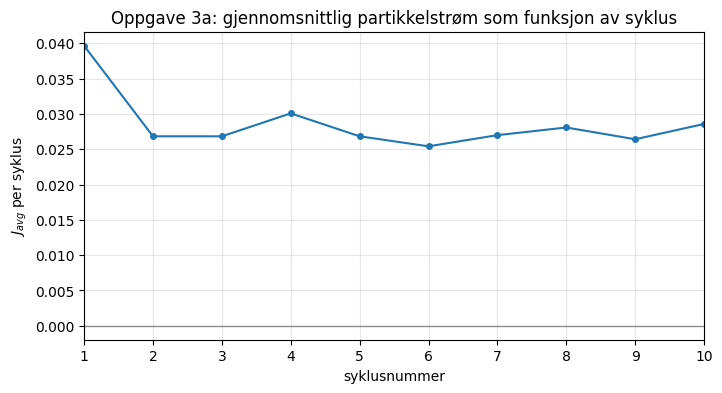

,syklus n,$J_{avg}(n)$
0,1,0.039667
1,2,0.026833
2,3,0.026832
3,4,0.030084
4,5,0.026833
5,6,0.025417
6,7,0.027000
7,8,0.028083
8,9,0.026417
9,10,0.028583


In [187]:
plot_oppgave_3a(params_oppgave_3, alfa = 0.1)

# Oppgave 3b)

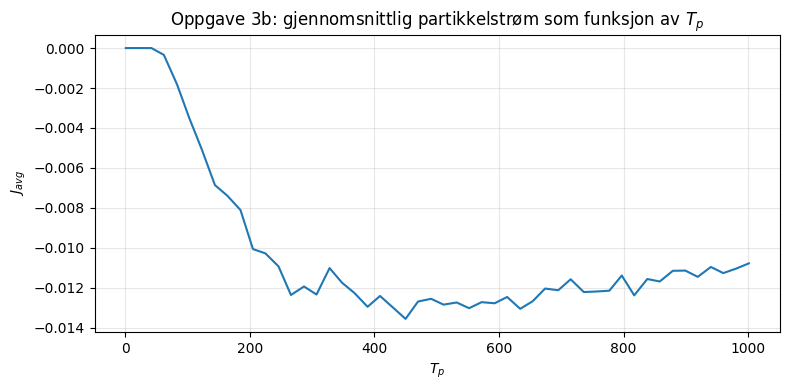

In [188]:
plot_oppgave_3b(params_oppgave_3)

# Oppgave 3c)

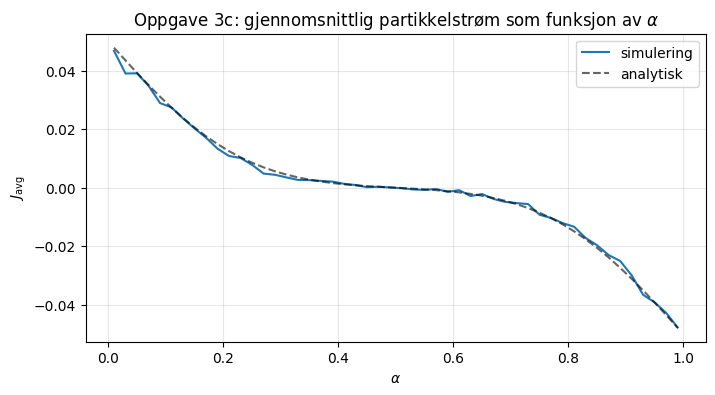

In [189]:
plot_oppgave_3c(params_oppgave_3)

# Oppgave 3d)

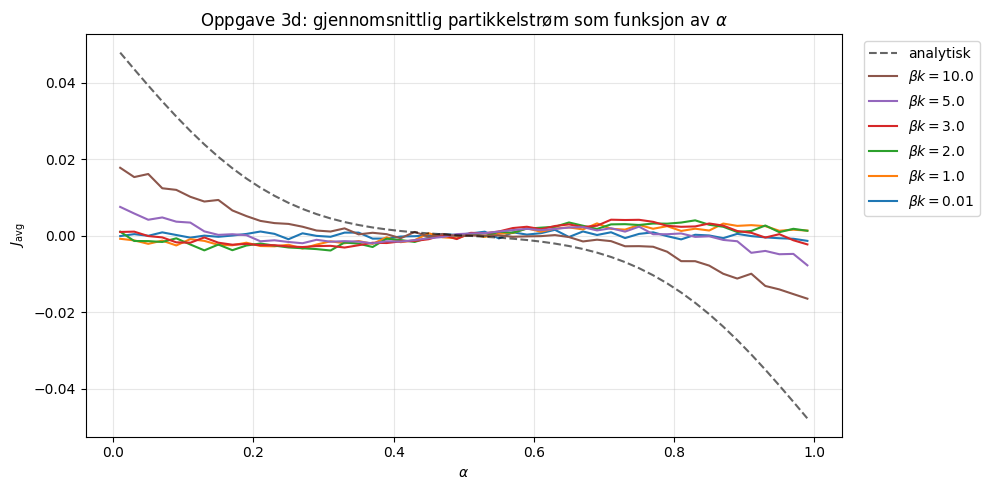

In [190]:
plot_oppgave_3d(params_oppgave_3)

# Oppgave 3e)

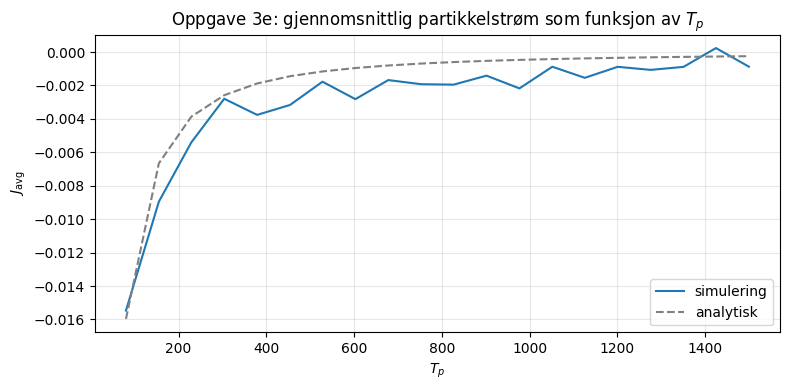

In [191]:
plot_oppgave_3e(params_oppgave_3)

# Oppgave 3f)

SKRIVEOPPGAVE